## EDA With Red Wine Data

Data Set Information:

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine.  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

These datasets can be viewed as classification or regression tasks. The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods.


Attribute Information:

Input variables (based on physicochemical tests):
- 1 - fixed acidity
- 2 - volatile acidity
- 3 - citric acid
- 4 - residual sugar
- 5 - chlorides
- 6 - free sulfur dioxide
- 7 - total sulfur dioxide
- 8 - density
- 9 - pH
- 10 - sulphates
- 11 - alcohol

Output variable (based on sensory data):
- 12 - quality (score between 0 and 10)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline
import time # for time related functions
import random # for generating random numbers
import warnings # to ignore warnings

random.seed(100)

In [4]:
# load the wine quality dataset
df  = pd.read_csv('winequality-red.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
df.info()  # Display the structure of the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.describe()  # Display summary statistics of the DataFrame

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
df.shape  # Display the shape of the DataFrame

(1599, 12)

In [9]:
df.columns  # Display the column names of the DataFrame

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [10]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [16]:
df.isnull().sum()  # Check for missing values in the DataFrame

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [18]:
df[df.duplicated()] # Check for duplicate rows in the DataFrame

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


In [19]:
df.drop_duplicates(inplace=True) # Remove duplicate rows from the DataFrame

In [20]:
df.shape  # Display the shape of the DataFrame

(1359, 12)

In [22]:
df.corr()  # Display the correlation matrix of the DataFrame

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


# Univariate Analysis

Text(0.5, 0, 'Alcohol Content')

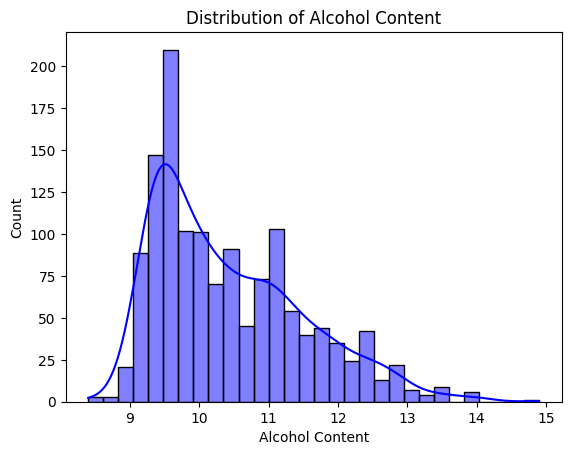

In [29]:
sns.histplot(df['alcohol'], kde=True, bins=30, color='blue')  # Create a histogram with a kernel density estimate (KDE) for the 'alcohol' column
plt.title('Distribution of Alcohol Content')  # Set the title of the histogram
plt.xlabel('Alcohol Content')  # Set the x-axis label

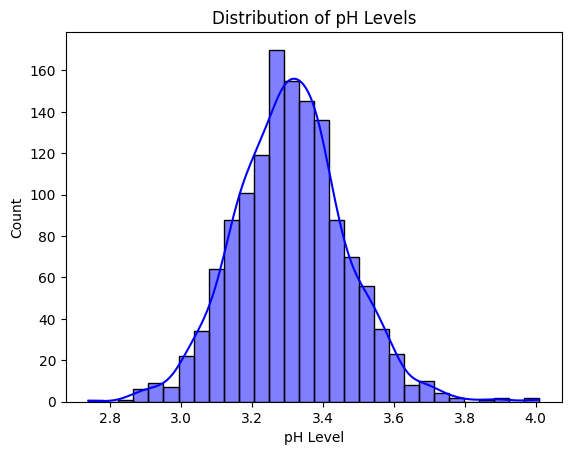

In [43]:
sns.histplot(df['pH'], kde=True, bins=30, color='blue')  # Create a histogram with a kernel density estimate (KDE) for the 'pH' column
plt.title('Distribution of pH Levels')  # Set the title of the histogram
plt.xlabel('pH Level')  # Set the x-axis label
plt.show()  # Display the histogram

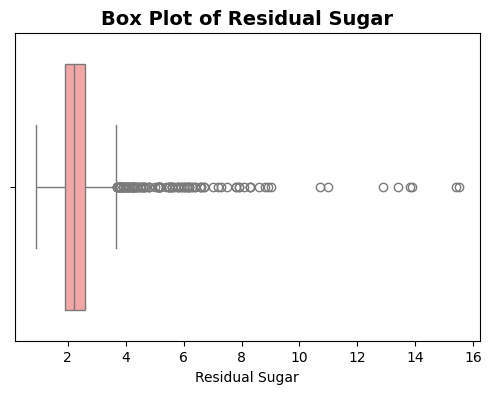

In [48]:

feature = "residual sugar"  # Specify the feature for the box plot

# Create a box plot
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[feature], color="#ff9999")  # soft red for wine vibes
plt.title(f"Box Plot of {feature.title()}", fontsize=14, fontweight='bold')
plt.xlabel(feature.title())
plt.show()


C:\Users\keshav pal\AppData\Local\Temp\ipykernel_5864\3916705305.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')  # Create a count plot for the 'quality' column where 'viridis' is the color palette


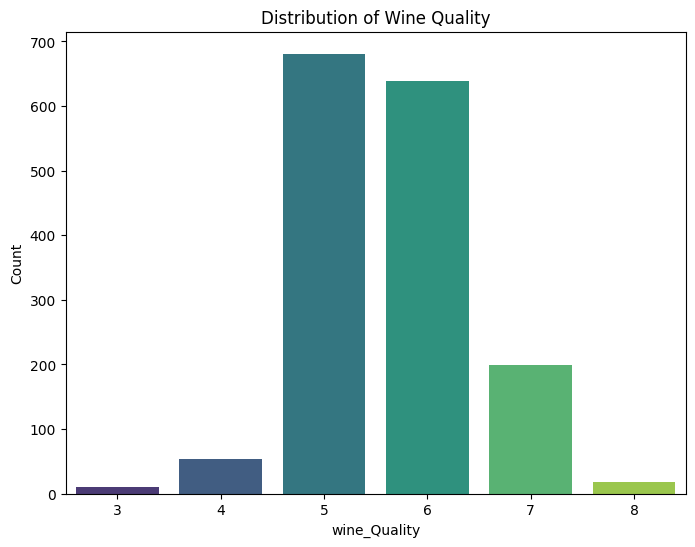

In [60]:
# Visualize the distribution of the 'quality' column
plt.figure(figsize=(8, 6))  # Set the figure size
sns.countplot(x='quality', data=df, palette='viridis')  # Create a count plot for the 'quality' column where 'viridis' is the color palette
plt.title('Distribution of Wine Quality')  # Set the title of the plot
plt.xlabel('wine_Quality')  # Set the x-axis label
plt.ylabel('Count')  # Set the y-axis label
plt.show()  # Display the plot


# Bivariate Analysis

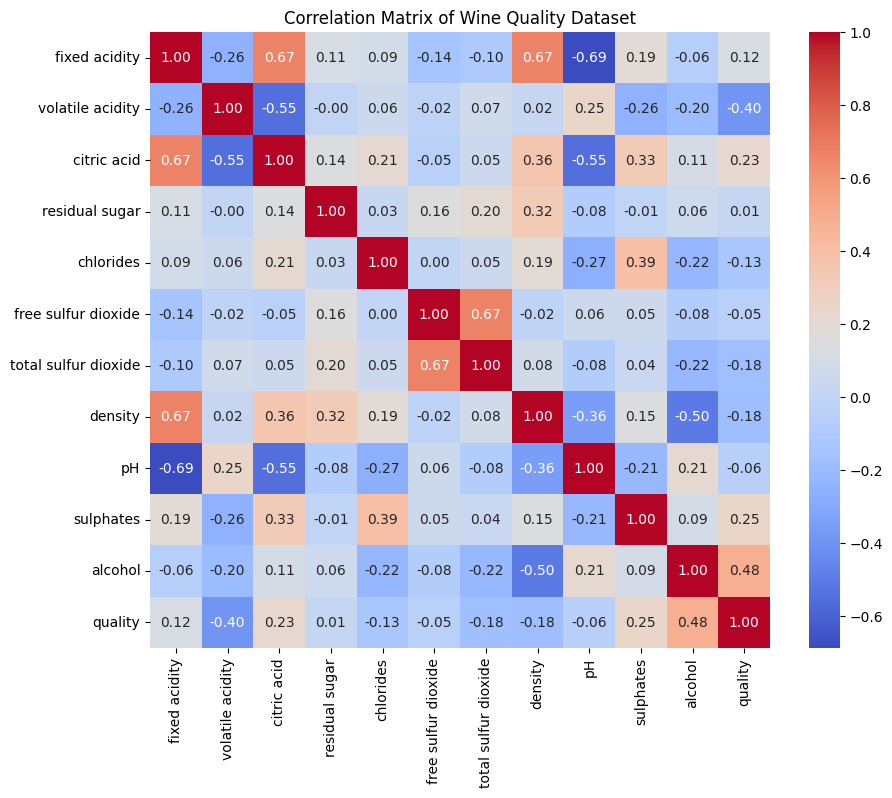

In [49]:
plt.figure(figsize=(10, 8)) # Create a figure with specified size
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')  # Create a heatmap of the correlation matrix where fmt='.2f' formats the annotations to two decimal places
plt.title('Correlation Matrix of Wine Quality Dataset')  # Set the title of the heatmap
plt.show()  # Display the heatmap


C:\Users\keshav pal\AppData\Local\Temp\ipykernel_5864\3959308941.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='residual sugar', data=df, palette='Set2')  # Create a box plot to visualize the distribution of 'residual sugar' across different 'quality' levels


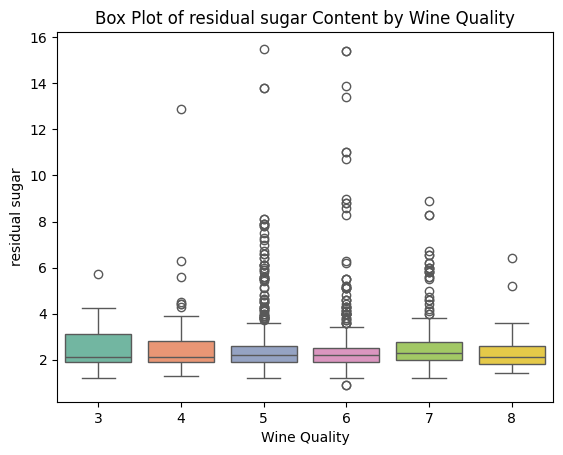

In [59]:

sns.boxplot(x='quality', y='residual sugar', data=df, palette='Set2')  # Create a box plot to visualize the distribution of 'residual sugar' across different 'quality' levels
plt.title('Box Plot of residual sugar Content by Wine Quality')  # Set the title of the
plt.xlabel('Wine Quality')  # Set the x-axis label
plt.ylabel('residual sugar')  # Set the y-axis label
plt.show()  # Display the box plot


C:\Users\keshav pal\AppData\Local\Temp\ipykernel_5864\3204768135.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='citric acid', data=df, palette='Set2')  # Create a box plot to visualize the distribution of 'citric acid' across different 'quality' levels


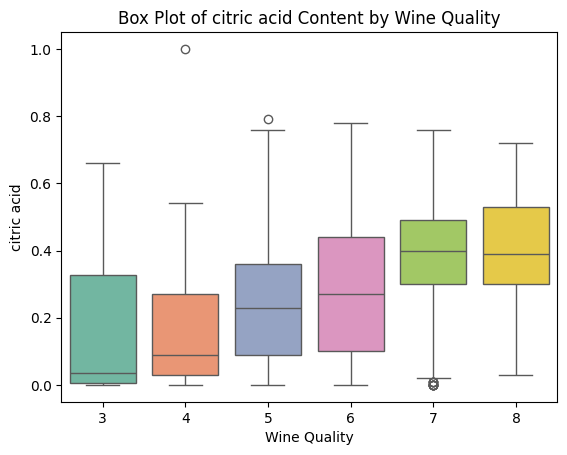

In [50]:

sns.boxplot(x='quality', y='citric acid', data=df, palette='Set2')  # Create a box plot to visualize the distribution of 'citric acid' across different 'quality' levels
plt.title('Box Plot of citric acid Content by Wine Quality')  # Set the title of the
plt.xlabel('Wine Quality')  # Set the x-axis label
plt.ylabel('citric acid')  # Set the y-axis label
plt.show()  # Display the box plot


C:\Users\keshav pal\AppData\Local\Temp\ipykernel_5864\2409402176.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=df, palette='Set2')  # Create a box plot to visualize the distribution of 'alcohol' across different 'quality' levels


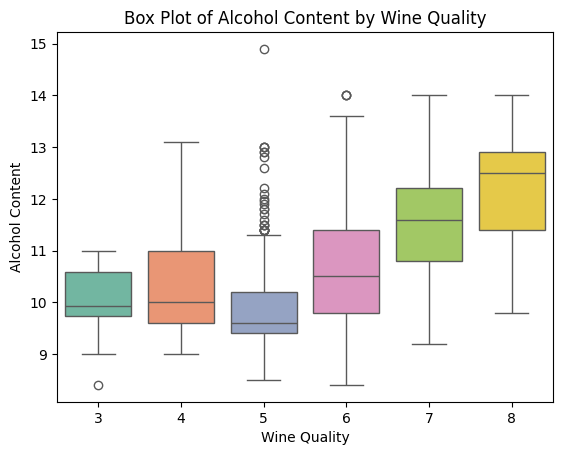

In [30]:

sns.boxplot(x='quality', y='alcohol', data=df, palette='Set2')  # Create a box plot to visualize the distribution of 'alcohol' across different 'quality' levels
plt.title('Box Plot of Alcohol Content by Wine Quality')  # Set the title of the
plt.xlabel('Wine Quality')  # Set the x-axis label
plt.ylabel('Alcohol Content')  # Set the y-axis label
plt.show()  # Display the box plot


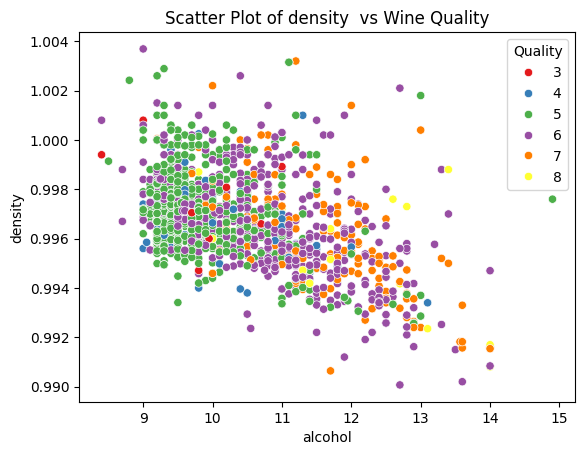

In [47]:

sns.scatterplot(x='alcohol', y='density', data=df, hue='quality', palette='Set1')  # Create a scatter plot to visualize the relationship between 'density' and 'quality'
plt.title('Scatter Plot of density  vs Wine Quality')  # Set the title of the
plt.xlabel('alcohol')  # Set the x-axis label
plt.ylabel('density')  # Set the y-axis label
plt.legend(title='Quality')  # Add a legend with title 'Quality'
plt.show()  # Display the scatter plot


C:\Users\keshav pal\AppData\Local\Temp\ipykernel_5864\2273764351.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


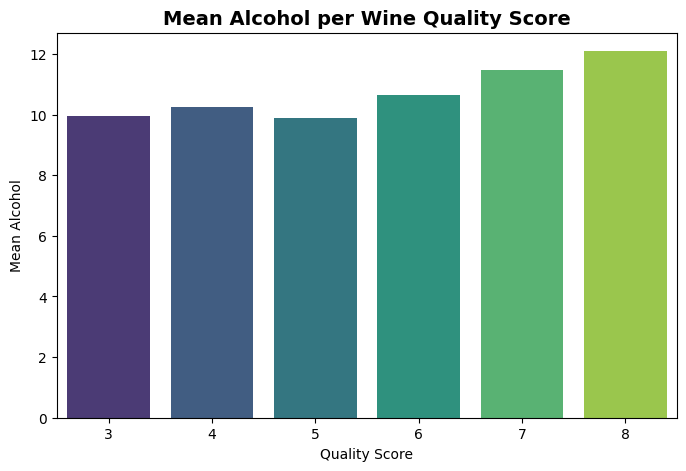

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("winequality-red.csv")

# 2. Choose the chemical property
feature = "alcohol"   # try "volatile acidity", "residual sugar", etc.

# 3. Group by quality and calculate mean
grouped_df = df.groupby("quality")[feature].mean().reset_index()

# 4. Plot
plt.figure(figsize=(8,5))
sns.barplot(
    data=grouped_df,
    x="quality",
    y=feature,
    palette="viridis"
)
plt.title(f"Mean {feature.title()} per Wine Quality Score", fontsize=14, fontweight="bold")
plt.xlabel("Quality Score")
plt.ylabel(f"Mean {feature.title()}")
plt.show()

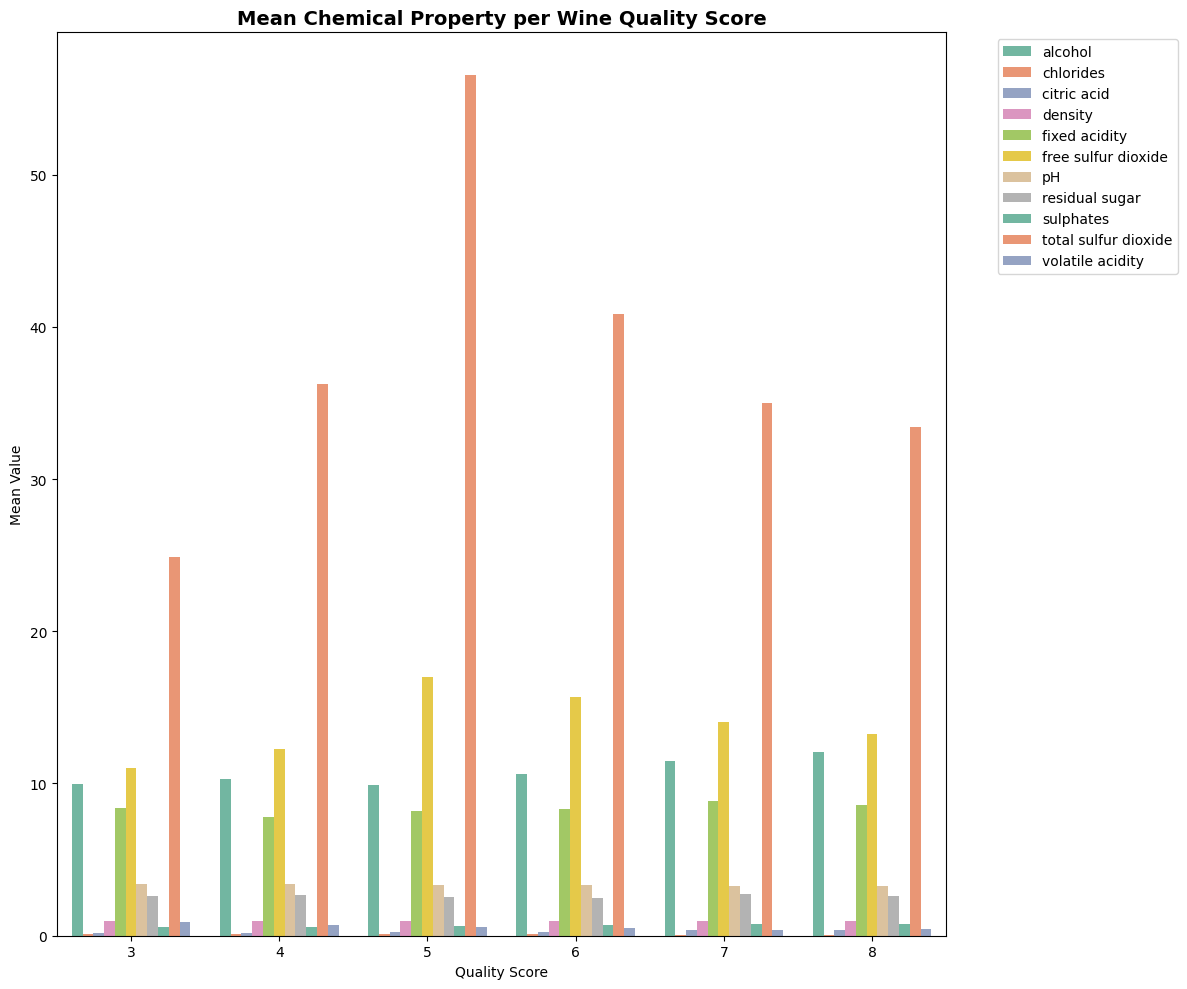

In [53]:
# Select only numeric features (exclude 'quality')
num_cols = df.select_dtypes(include="number").columns.drop("quality")

# Melt dataframe: long format for Seaborn
df_melted = df.melt(id_vars="quality", value_vars=num_cols, 
                    var_name="Chemical Property", value_name="Value")

# Calculate mean per quality per property
mean_df = df_melted.groupby(["quality", "Chemical Property"])["Value"].mean().reset_index()

# Plot grouped bars
plt.figure(figsize=(12,10))
sns.barplot(
    data=mean_df,
    x="quality",
    y="Value",
    hue="Chemical Property",
    palette="Set2"
)
plt.title("Mean Chemical Property per Wine Quality Score", fontsize=14, fontweight="bold")
plt.xlabel("Quality Score")
plt.ylabel("Mean Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Multiple Variate

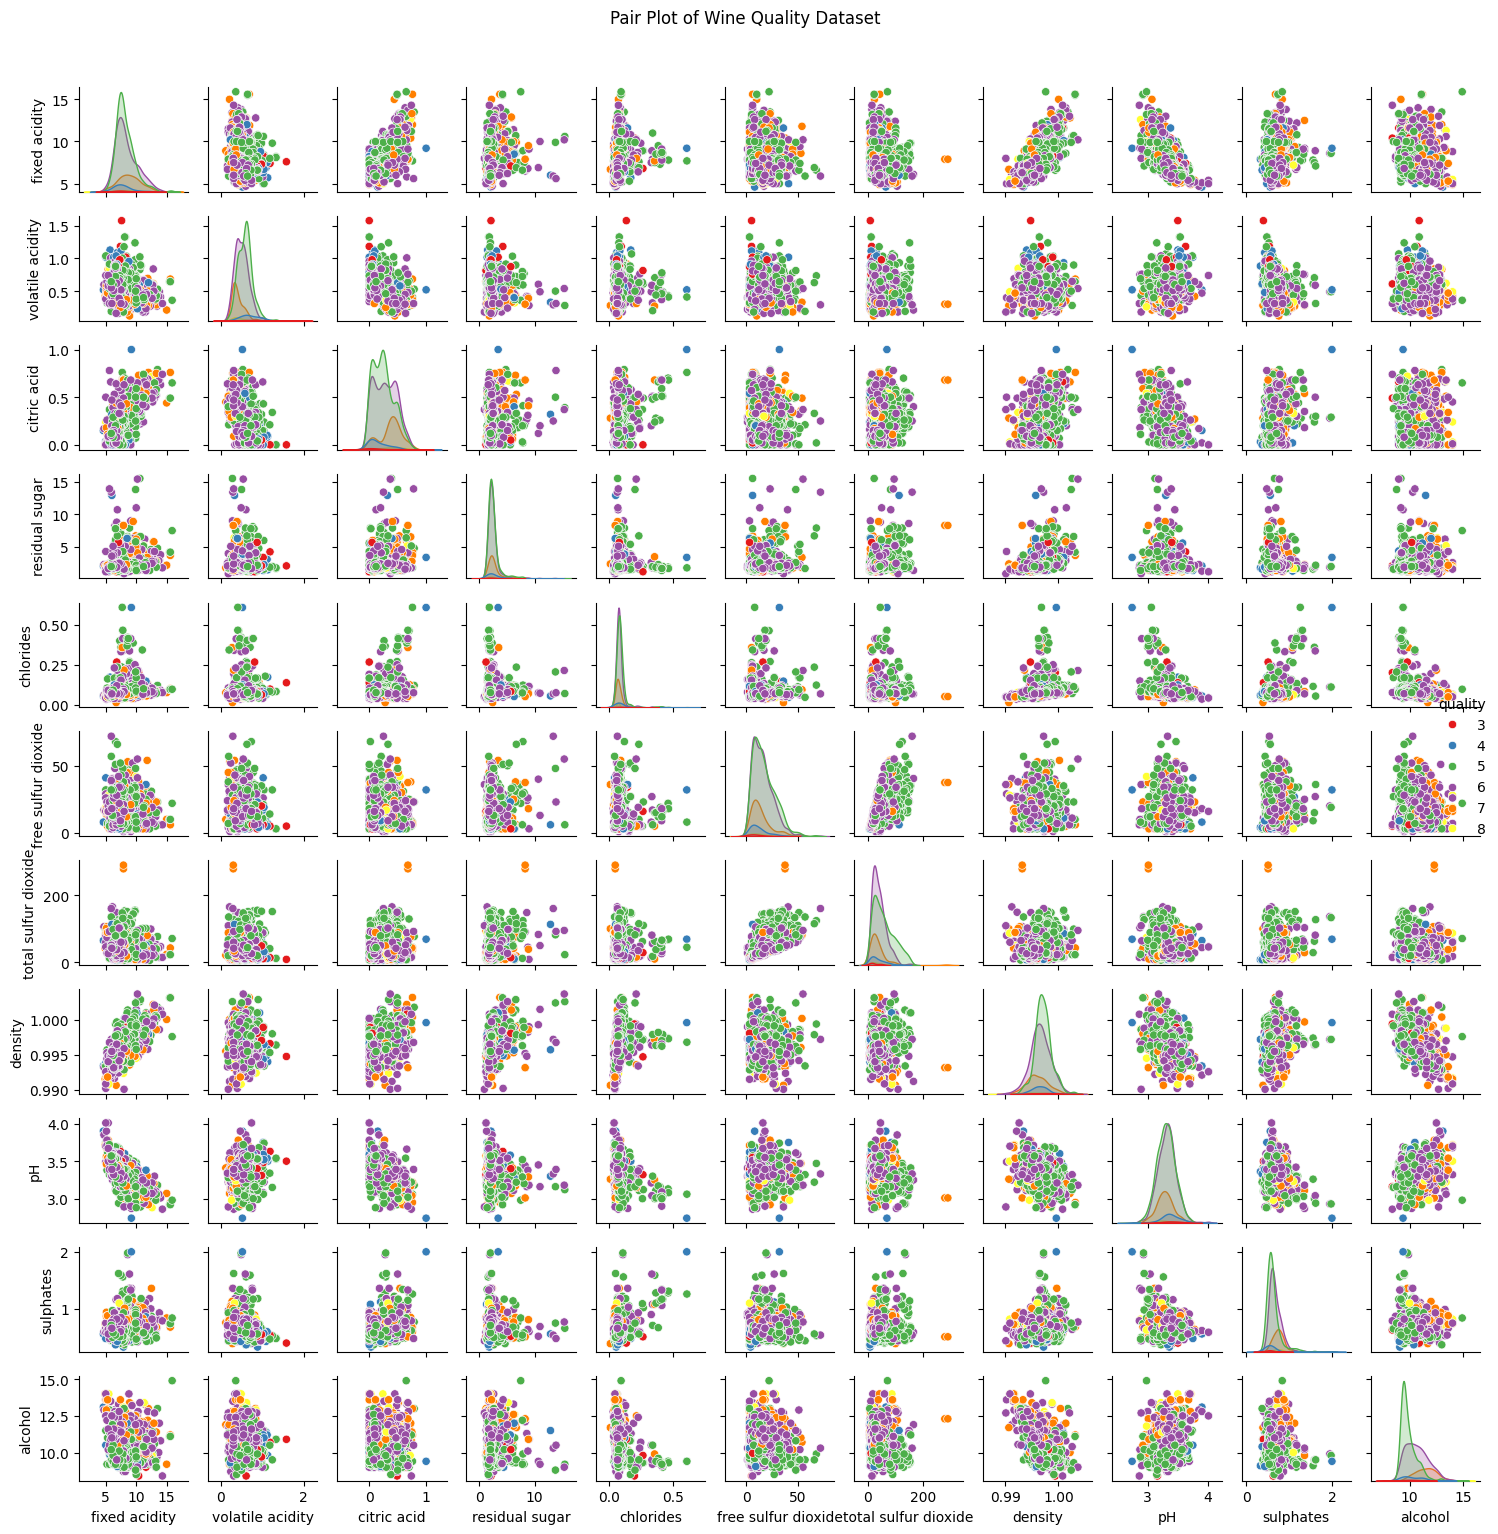

In [35]:

sns.pairplot(df, hue='quality', palette='Set1')  # Create a pair plot to visualize relationships between all numerical features, colored by 'quality'
figure = plt.gcf()  # Get the current figure
figure.set_size_inches(15, 15)  # Set the size of the figure    
plt.suptitle('Pair Plot of Wine Quality Dataset', y=1.02) # Set the title of the pair plot with a slight offset
plt.tight_layout()  # Adjust the layout to prevent overlap
plt.show()  # Display the pair plot


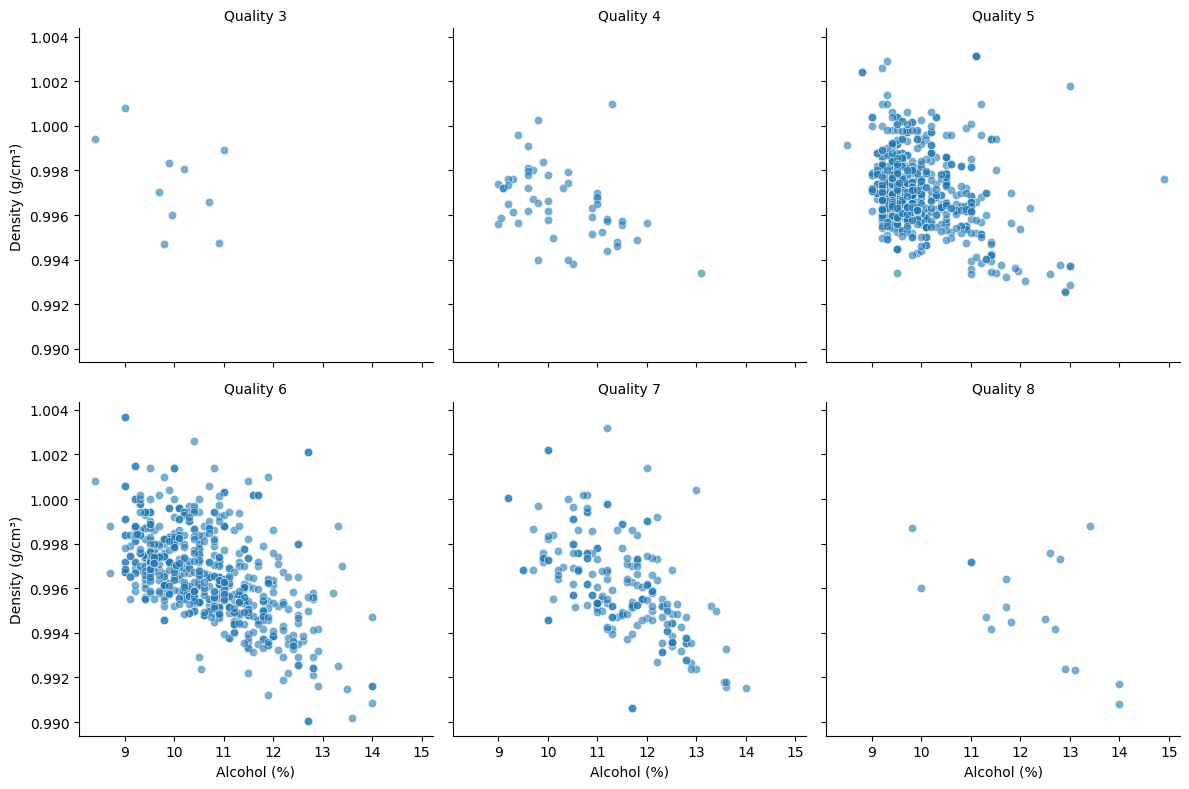

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load red wine dataset
df = pd.read_csv("winequality-red.csv")

# Initialize FacetGrid
g = sns.FacetGrid(df, col="quality", col_wrap=3, height=4)  
# col="quality" → one facet per quality score  
# col_wrap=3 → wrap after 3 columns to start new row

# Add scatterplot to each facet
g.map_dataframe(sns.scatterplot, x="alcohol", y="density", alpha=0.6)

# Add titles & adjust
g.set_axis_labels("Alcohol (%)", "Density (g/cm³)")
g.set_titles(col_template="Quality {col_name}")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Example: Wine dataset
df = pd.read_csv("winequality-red.csv")

# 1️ Select numeric features
X = df.select_dtypes(include='number')

# 2️ Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3️ Apply PCA (keep 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4️ Create a DataFrame of results
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print(pca_df.head())

Explained Variance Ratio: [0.26009731 0.1868235 ]
        PC1       PC2
0 -1.779442 -1.157303
1 -1.004185 -2.071838
2 -0.915783 -1.393434
3  2.404077  0.213792
4 -1.779442 -1.157303


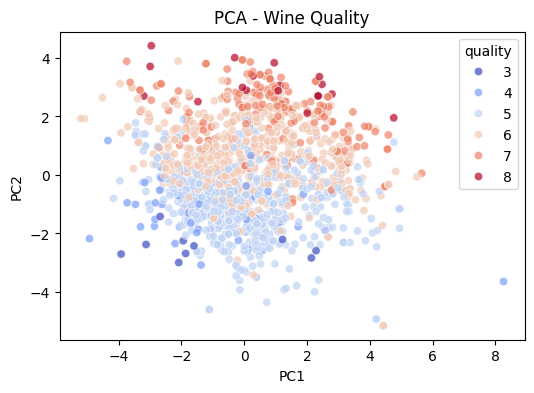

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(x=pca_df.PC1, y=pca_df.PC2, hue=df['quality'], palette='coolwarm', alpha=0.7)
plt.title('PCA - Wine Quality')
plt.show()

C:\Users\keshav pal\AppData\Local\Temp\ipykernel_5864\4126062817.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='quality', y='alcohol', data=df, palette='Set2')  # Create a violin plot to visualize the distribution of 'alcohol' across different 'quality' levels


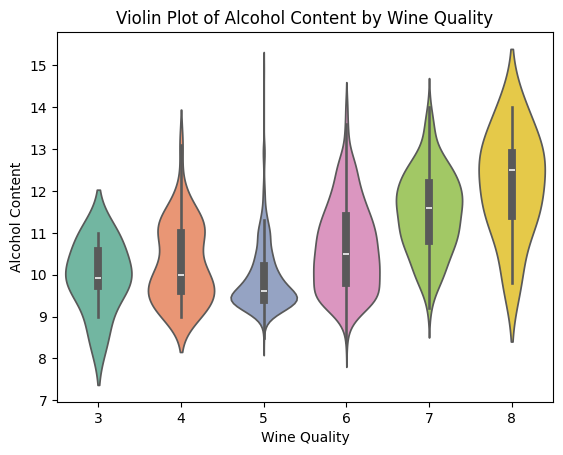

In [36]:

sns.violinplot(x='quality', y='alcohol', data=df, palette='Set2')  # Create a violin plot to visualize the distribution of 'alcohol' across different 'quality' levels
plt.title('Violin Plot of Alcohol Content by Wine Quality')  # Set the title of
plt.xlabel('Wine Quality')  # Set the x-axis label
plt.ylabel('Alcohol Content')  # Set the y-axis label
plt.show()  # Display the violin plot


C:\Users\keshav pal\AppData\Local\Temp\ipykernel_5864\4141538242.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='quality', y='alcohol', data=df, palette='Set2')  # Create a bar plot to visualize the average 'alcohol' content for each 'quality' level


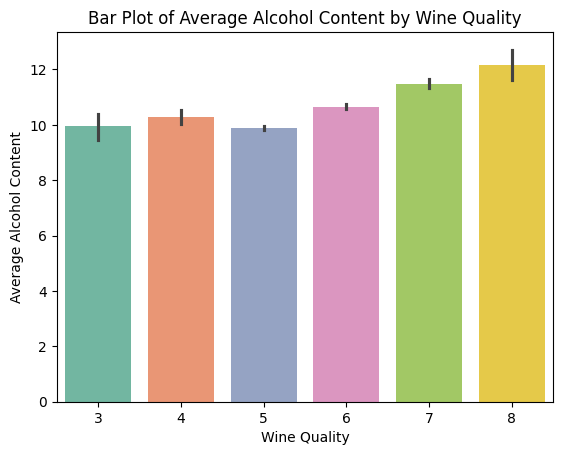

In [37]:

sns.barplot(x='quality', y='alcohol', data=df, palette='Set2')  # Create a bar plot to visualize the average 'alcohol' content for each 'quality' level
plt.title('Bar Plot of Average Alcohol Content by Wine Quality')  # Set the title of the bar plot
plt.xlabel('Wine Quality')  # Set the x-axis label
plt.ylabel('Average Alcohol Content')  # Set the y-axis label
plt.show()  # Display the bar plot


C:\Users\keshav pal\AppData\Local\Temp\ipykernel_5864\4060998569.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='quality', y='alcohol', data=df, marker='o', palette='Set2')  # Create a line plot to visualize the trend of 'alcohol' content across different 'quality' levels


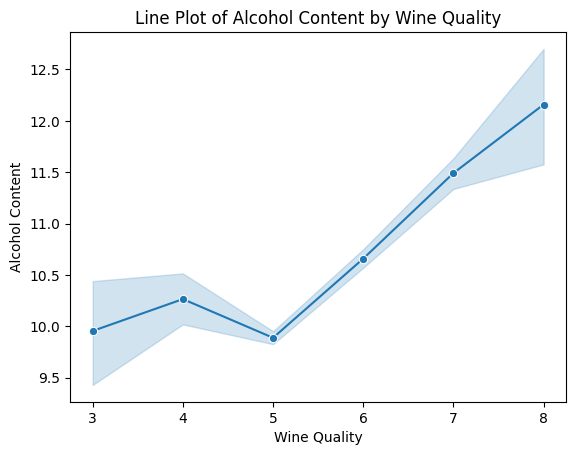

In [38]:

sns.lineplot(x='quality', y='alcohol', data=df, marker='o', palette='Set2')  # Create a line plot to visualize the trend of 'alcohol' content across different 'quality' levels
plt.title('Line Plot of Alcohol Content by Wine Quality')  # Set the title of the
plt.xlabel('Wine Quality')  # Set the x-axis label
plt.ylabel('Alcohol Content')  # Set the y-axis label
plt.show()  # Display the line plot


<Axes: xlabel='alcohol', ylabel='pH'>

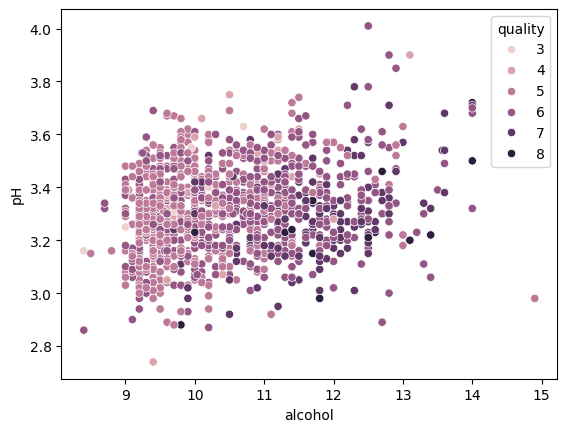

In [39]:
sns.scatterplot(x='alcohol',y='pH',hue='quality',data=df)